ARTI308 - Machine Learning


# Lab 5: Feature Engineering (Classification)
## Order Status Prediction using a Talabat-style Orders Dataset

### Lab focus
This dataset is already clean (no missing values, no duplicate rows, consistent data types). 

In this lab, we focus on **feature engineering** for a classification task.

### Objective
Build a baseline model to predict `Order_Status` (Delivered, Cancelled, In Transit) and learn how feature engineering choices affect model performance and feature importance. 

## 1. Setup and imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
DATA_PATH = "talabat_enhanced_orders2.csv"  # ensure the file is in the same folder as this notebook
df = pd.read_csv(DATA_PATH)

df.head(10)

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,56795,U4934,991,313,Sushi,5,305.65,2025-06-11 14:37:00,2025-06-11 14:58:00,21,Giza,Wallet,Delivered,Car,30.011739,31.220610,30.019520,31.196654,30.026240,31.200332,2.466822,Medium,Online
1,81167,U8701,151,316,Pizza,4,446.40,2025-06-08 20:13:00,2025-06-08 20:49:00,36,Cairo,Cash,In Transit,Car,30.045413,31.223939,30.062724,31.220663,30.050536,31.237185,1.944823,Low,Online
2,75889,U7689,138,363,Koshary,3,394.50,2025-06-07 03:29:00,2025-06-07 04:20:00,51,Mansoura,Credit Card,Delivered,Car,31.057534,31.366192,31.045638,31.373109,31.020001,31.399328,1.475038,Low,Online
3,34786,U7076,540,258,Burger,4,139.20,2025-06-09 20:49:00,2025-06-09 21:30:00,41,Tanta,Wallet,Cancelled,Bicycle,30.787492,30.993809,30.789228,30.984042,30.805722,30.997262,0.954482,Low,Online
4,38475,U6245,847,110,Salad,2,207.02,2025-06-08 12:05:00,2025-06-08 12:33:00,28,Tanta,Credit Card,Cancelled,Bicycle,30.803427,30.983386,30.768538,30.992124,30.792271,30.987854,3.957460,Medium,Online
5,88329,U3379,454,90,Sandwich,1,125.68,2025-06-02 04:02:00,2025-06-02 04:33:00,31,Alexandria,Cash,Delivered,Car,31.180300,29.922967,31.180552,29.899449,31.211355,29.929651,2.242070,Low,Online
6,79499,U3029,168,479,Sushi,2,243.62,2025-06-15 01:06:00,2025-06-15 01:59:00,53,Giza,Credit Card,Delivered,Motorbike,30.013826,31.215348,30.020233,31.228303,29.995995,31.212204,1.437552,Low,Online
7,27325,U3674,473,321,Fried Chicken,1,149.87,2025-06-04 01:02:00,2025-06-04 01:53:00,51,Tanta,Cash,Cancelled,Car,30.794454,30.998586,30.791487,31.002607,30.799764,31.006845,0.506267,Low,Online
8,73621,U8696,704,42,Pasta,4,562.32,2025-06-14 06:45:00,2025-06-14 07:33:00,48,Zagazig,Credit Card,Delivered,Car,30.573653,31.508104,30.602105,31.519432,30.587649,31.500689,3.336044,Low,Online
9,18180,U3260,458,183,Pasta,5,194.95,2025-06-03 02:50:00,2025-06-03 03:15:00,25,Alexandria,Cash,Delivered,Motorbike,31.193297,29.906175,31.187237,29.913781,31.202042,29.926440,0.988472,Low,Online


The first rows confirm that the dataset loaded correctly.  
Each row represents one food delivery order, including information about the customer, restaurant, driver, and order outcome (`Order_Status`).

## 3. Quick dataset checks

In [3]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (25000, 23)

Missing values per column:


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


We confirm the dataset is clean: no missing values and no duplicated rows.  
Therefore, we will spend our effort on feature engineering rather than cleaning.

## 4. Target variable and class balance

In [4]:
target_col = "Order_Status"
df[target_col].value_counts()

Order_Status
Delivered     10197
Cancelled      9812
In Transit     4991
Name: count, dtype: int64

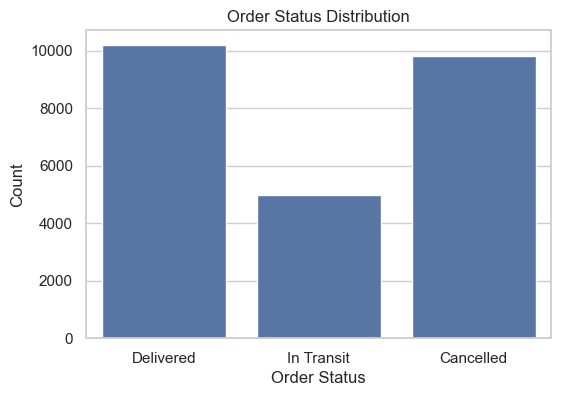

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

This bar chart shows whether the classes are balanced.  
If one class dominates, the model may learn to predict that class more often, so we must interpret accuracy carefully and also look at the confusion matrix.

## 5. Identify feature types

In [6]:
df.dtypes

Order_ID                       int64
User_ID                       object
Restaurant_ID                  int64
Driver_ID                      int64
Item_Name                     object
Quantity                       int64
Total_Price                  float64
Order_Time                    object
Delivery_Time                 object
Delivery_Duration_Minutes      int64
City                          object
Payment_Method                object
Order_Status                  object
Driver_Vehicle                object
Restaurant_Lat               float64
Restaurant_Lon               float64
Customer_Lat                 float64
Customer_Lon                 float64
Driver_Lat                   float64
Driver_Lon                   float64
Delivery_Distance_km         float64
Traffic_Level                 object
Driver_Availability           object
dtype: object

We have a mixture of numerical features (e.g., `Quantity`, `Total_Price`, distances) and categorical features (e.g., `City`, `Payment_Method`, `Traffic_Level`).  
This is a common real-world situation where feature engineering and encoding become essential.


## 6. Leakage awareness (important)

When designing a prediction task, we must avoid using features that would not be available at prediction time.

For example, if we want to predict the order status **right after the customer places the order**, we should not use:
- `Delivery_Time` (known only later)
- `Delivery_Duration_Minutes` (known only after delivery)

In this lab, we will **exclude** obvious leakage features and focus on information that is typically available early in the order lifecycle.

In [7]:
drop_cols = ["Delivery_Time", "Delivery_Duration_Minutes"]

# keep only existing columns
drop_cols = [c for c in drop_cols if c in df.columns]

# drop from dataframe
df = df.drop(columns=drop_cols)

## 7. Feature engineering

### 7.1 Time-based features from `Order_Time`
We convert `Order_Time` into a datetime, then extract:
- hour of day  
- day of week  
- weekend flag  
- peak hour flag (example rule: lunch and dinner periods)


In [8]:
df_fe = df.copy()

# Parse time columns
df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"], errors="coerce")

df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek  # Monday=0, Sunday=6
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([5,6]).astype(int)

# Simple peak-hour rule (you can adjust based on local context):
# Lunch: 12-15, Dinner: 19-23
df_fe["is_peak_hour"] = df_fe["order_hour"].isin(list(range(12,16)) + list(range(19,24))).astype(int)

df_fe[["Order_Time","order_hour","order_dayofweek","is_weekend","is_peak_hour"]].head(10)


,Order_Time,order_hour,order_dayofweek,is_weekend,is_peak_hour
0,2025-06-11 14:37:00,14,2,0,1
1,2025-06-08 20:13:00,20,6,1,1
2,2025-06-07 03:29:00,3,5,1,0
3,2025-06-09 20:49:00,20,0,0,1
4,2025-06-08 12:05:00,12,6,1,1
5,2025-06-02 04:02:00,4,0,0,0
6,2025-06-15 01:06:00,1,6,1,0
7,2025-06-04 01:02:00,1,2,0,0
8,2025-06-14 06:45:00,6,5,1,0
9,2025-06-03 02:50:00,2,1,0,0


We transformed the original timestamp into multiple meaningful features.  
Models often learn better from these engineered features than from raw timestamps.

### 7.2 Price-based features
We create a feature that captures the price per item:
`price_per_item = Total_Price / Quantity`

This can help the model differentiate between an expensive order with few items and a cheaper order with many items.

In [9]:
df_fe["price_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]
df_fe[["Quantity","Total_Price","price_per_item"]].head(10)

,Quantity,Total_Price,price_per_item
0,5,305.65,61.13
1,4,446.40,111.60
2,3,394.50,131.50
3,4,139.20,34.80
4,2,207.02,103.51
5,1,125.68,125.68
6,2,243.62,121.81
7,1,149.87,149.87
8,4,562.32,140.58
9,5,194.95,38.99


`price_per_item` is a derived feature that may reflect restaurant type, item category, or order complexity.  
It is an example of business-driven feature engineering.

### 7.3 Optional: Haversine distance from GPS coordinates
The dataset already includes `Delivery_Distance_km`.  
However, if latitude/longitude columns exist, we can also compute an additional distance feature using the Haversine formula.

This section is **optional** and will only run if the coordinate columns exist.

In [10]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in kilometers."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

coord_cols = {"Restaurant_Lat","Restaurant_Lon","Customer_Lat","Customer_Lon"}
if coord_cols.issubset(set(df_fe.columns)):
    df_fe["haversine_rest_to_cust_km"] = haversine_km(
        df_fe["Restaurant_Lat"], df_fe["Restaurant_Lon"],
        df_fe["Customer_Lat"], df_fe["Customer_Lon"]
    )
    display(df_fe[["Delivery_Distance_km","haversine_rest_to_cust_km"]].head(10))
else:
    print("Coordinate columns not found. Skipping Haversine feature.")

,Delivery_Distance_km,haversine_rest_to_cust_km
0,2.466822,2.463521
1,1.944823,1.950558
2,1.475038,1.477900
3,0.954482,0.952771
4,3.957460,3.968334
5,2.242070,2.237553
6,1.437552,1.436513
7,0.506267,0.506320
8,3.336044,3.344290
9,0.988472,0.988730


If computed, `haversine_rest_to_cust_km` is a physics-based distance derived from coordinates.  
It can be used as an additional engineered feature, and it can also be compared with `Delivery_Distance_km` to understand how the dataset’s provided distance was generated.

### 7.4 Reducing high-cardinality categories 
#### (example: `Item_Name`)
`Item_Name` may have many unique values. If we one-hot encode all items, the feature space becomes huge.

A common feature engineering approach is to keep the most frequent categories and map the rest to `Other`.


In [11]:
df['Item_Name'].unique()

array(['Sushi', 'Pizza', 'Koshary', 'Burger', 'Salad', 'Sandwich',
       'Fried Chicken', 'Pasta', 'Shawarma'], dtype=object)

In [12]:
if "Item_Name" in df_fe.columns:
    top_k = 10
    top_items = df_fe["Item_Name"].value_counts().head(top_k).index
    df_fe["Item_Name_reduced"] = np.where(df_fe["Item_Name"].isin(top_items), df_fe["Item_Name"], "Other")
    print("Unique Item_Name:", df_fe["Item_Name"].nunique())
    print("Unique Item_Name_reduced:", df_fe["Item_Name_reduced"].nunique())
    df_fe[["Item_Name","Item_Name_reduced"]].head(10)
else:
    print("Item_Name column not found.")

Unique Item_Name: 9
Unique Item_Name_reduced: 9


We reduced the cardinality of a text category feature.  
This often improves model stability and reduces overfitting, especially for baseline models.

## 8. Discretization (binning)

Discretization converts a continuous numerical feature into categories (bins).  
This can help some models capture non-linear relationships, and it also improves interpretability.

Here we discretize `Total_Price` into simple tiers.


In [13]:
df_fe["price_tier"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0, 100, 250, 500, np.inf],
    labels=["low","medium","high","very_high"]
)

df_fe[["Total_Price","price_tier"]].head(10)

,Total_Price,price_tier
0,305.65,high
1,446.40,high
2,394.50,high
3,139.20,medium
4,207.02,medium
5,125.68,medium
6,243.62,medium
7,149.87,medium
8,562.32,very_high
9,194.95,medium


`price_tier` groups numeric values into understandable categories.  
This may help capture patterns such as higher cancellation rates for very expensive orders, if such a trend exists.

In [14]:
df_fe.head()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,order_hour,order_dayofweek,is_weekend,is_peak_hour,price_per_item,haversine_rest_to_cust_km,Item_Name_reduced,price_tier
0,56795,U4934,991,313,Sushi,5,305.65,2025-06-11 14:37:00,Giza,Wallet,Delivered,Car,30.011739,31.220610,30.019520,31.196654,30.026240,31.200332,2.466822,Medium,Online,14,2,0,1,61.13,2.463521,Sushi,high
1,81167,U8701,151,316,Pizza,4,446.40,2025-06-08 20:13:00,Cairo,Cash,In Transit,Car,30.045413,31.223939,30.062724,31.220663,30.050536,31.237185,1.944823,Low,Online,20,6,1,1,111.60,1.950558,Pizza,high
2,75889,U7689,138,363,Koshary,3,394.50,2025-06-07 03:29:00,Mansoura,Credit Card,Delivered,Car,31.057534,31.366192,31.045638,31.373109,31.020001,31.399328,1.475038,Low,Online,3,5,1,0,131.50,1.477900,Koshary,high
3,34786,U7076,540,258,Burger,4,139.20,2025-06-09 20:49:00,Tanta,Wallet,Cancelled,Bicycle,30.787492,30.993809,30.789228,30.984042,30.805722,30.997262,0.954482,Low,Online,20,0,0,1,34.80,0.952771,Burger,medium
4,38475,U6245,847,110,Salad,2,207.02,2025-06-08 12:05:00,Tanta,Credit Card,Cancelled,Bicycle,30.803427,30.983386,30.768538,30.992124,30.792271,30.987854,3.957460,Medium,Online,12,6,1,1,103.51,3.968334,Salad,medium


## 9. Prepare features for modeling

We now select our predictors.

We will drop:
- IDs that do not represent meaningful signals by themselves
- Obvious leakage features (`Delivery_Time`, `Delivery_Duration_Minutes`)

We will keep:
- early-available numeric and categorical variables
- engineered features

In [15]:
drop_cols = [
    "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID","Total_Price","haversine_rest_to_cust_km",
    "Order_Time","Item_Name"  # we replaced it with Item_Name_reduced
]

# keep only columns that exist (safe for future versions of the dataset)
drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (25000, 20)
y shape: (25000,)


In [16]:
X.columns

Index(['Quantity', 'City', 'Payment_Method', 'Driver_Vehicle',
       'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon',
       'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'Traffic_Level',
       'Driver_Availability', 'order_hour', 'order_dayofweek', 'is_weekend',
       'is_peak_hour', 'price_per_item', 'Item_Name_reduced', 'price_tier'],
      dtype='object')

We prepared a feature matrix `X` and a target vector `y`.  
The feature matrix includes engineered features such as time-based indicators, price per item, and reduced item category.

## 10. Split into train and test sets

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (20000, 20)
Test size: (5000, 20)


We use stratified splitting to keep class proportions similar in train and test sets.  
This makes evaluation more reliable for classification problems with imbalanced classes.
## 11. Encoding

### Why encoding?
Machine learning models require numerical input.  
Categorical variables must be converted into numbers. Here we use **One-Hot Encoding** for nominal categories.

### Why Random Forest for this lab?
We use Random Forest as a baseline because:
- it handles mixed features well
- it is robust for teaching purposes
- it provides feature importance to help us interpret engineered features


In [19]:
# Identify categorical and numerical columns automatically
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()


print("Categorical columns:\n", categorical_cols,'\n')
print("Numeric columns:\n", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight=None
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model

Categorical columns:
 ['City', 'Payment_Method', 'Driver_Vehicle', 'Traffic_Level', 'Driver_Availability', 'Item_Name_reduced', 'price_tier'] 

Numeric columns:
 ['Quantity', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'order_hour', 'order_dayofweek', 'is_weekend', 'is_peak_hour', 'price_per_item']


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['City', 'Payment_Method',
                                                   'Driver_Vehicle',
                                                   'Traffic_Level',
                                                   'Driver_Availability',
                                                   'Item_Name_reduced',
                                                   'price_tier']),
                                                 ('num', 'passthrough',
                                                  ['Quantity', 'Restaurant_Lat',
                                                   'Restaurant_Lon',
                                                   'Customer_Lat',
                                                   'Customer_Lon', 'Driver_Lat',
                                                   'Driver_Lon',
                                                   'Delivery_Distance_km',
                                                   'order_hour',
                                                   'order_dayofweek',
                                                   'is_weekend', 'is_peak_hour',
                                                   'price_per_item'])])),
                ('rf',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

## 12. Train the model and evaluate

In [20]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.388

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.38      0.44      0.41      1963
   Delivered       0.40      0.52      0.45      2039
  In Transit       0.15      0.00      0.00       998

    accuracy                           0.39      5000
   macro avg       0.31      0.32      0.29      5000
weighted avg       0.34      0.39      0.35      5000



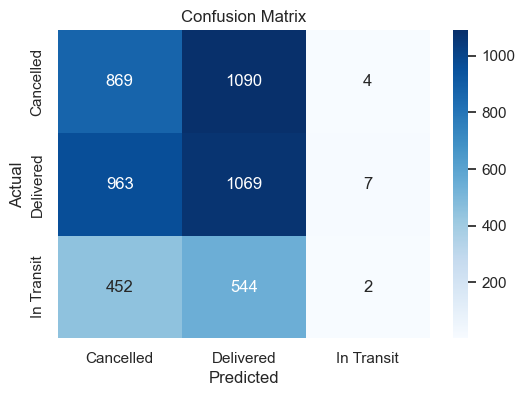

In [21]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy gives a general sense of performance, but the classification report is more informative.  
Precision answers: when the model predicts a class, how often is it correct?  
Recall answers: out of all real cases of a class, how many did the model find?

The confusion matrix shows which classes the model confuses most often.

## 13. Feature importance (What mattered the most?)

Random Forest provides a built-in feature importance score.  
Because we used one-hot encoding, each categorical value becomes its own feature.  
We will extract the final feature names and plot the top importances.

In [22]:
# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)

,feature,importance
43,price_per_item,0.079869
38,Delivery_Distance_km,0.079840
37,Driver_Lon,0.078046
35,Customer_Lon,0.077701
32,Restaurant_Lat,0.077555
36,Driver_Lat,0.077454
34,Customer_Lat,0.077225
33,Restaurant_Lon,0.077005
39,order_hour,0.054896
40,order_dayofweek,0.039833


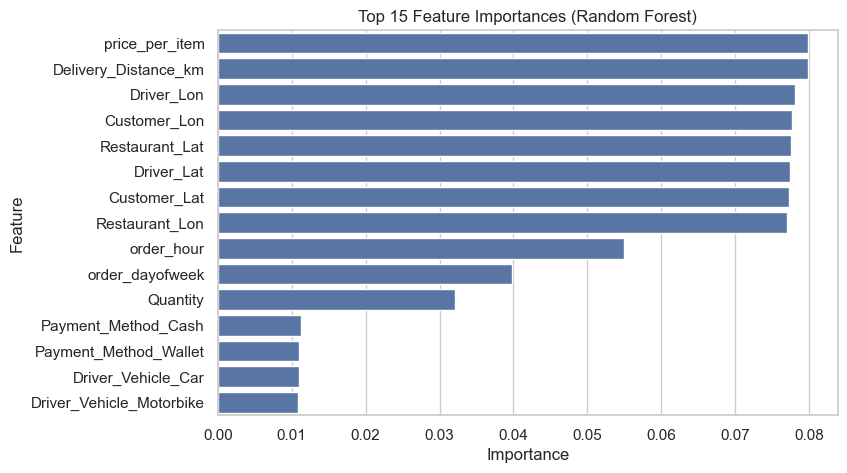

In [23]:
plt.figure(figsize=(8,5))
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

This chart helps us understand which engineered and original features contributed most to predicting `Order_Status`.  
A high importance score suggests the feature provides useful signal, but it does not automatically imply a causal relationship.

### Task
using the same dataset, change `top_k` in `Item_Name_reduced` (for example 3, 5, 6) and compare:
- accuracy
- top feature importances

In [27]:
top_k_values = [3, 5, 6]
results = {}

for top_k in top_k_values:
    print(f"\ntop_k = {top_k} ")

    df_exp = df.copy()

    # Reduce Item_Name categories
    top_items = df_exp["Item_Name"].value_counts().head(top_k).index
    df_exp["Item_Name_reduced"] = np.where(
        df_exp["Item_Name"].isin(top_items),
        df_exp["Item_Name"],
        "Other"
    )

    # Recreate engineered features
    df_exp["Order_Time"] = pd.to_datetime(df_exp["Order_Time"])
    df_exp["order_hour"] = df_exp["Order_Time"].dt.hour
    df_exp["order_dayofweek"] = df_exp["Order_Time"].dt.dayofweek
    df_exp["is_weekend"] = df_exp["order_dayofweek"].isin([5,6]).astype(int)
    df_exp["is_peak_hour"] = df_exp["order_hour"].isin(
        list(range(12,16)) + list(range(19,24))
    ).astype(int)
    df_exp["price_per_item"] = df_exp["Total_Price"] / df_exp["Quantity"]

    # Discretization
    df_exp["price_tier"] = pd.cut(
        df_exp["Total_Price"],
        bins=[0, 100, 250, 500, np.inf],
        labels=["low","medium","high","very_high"]
    )

    # Drop columns
    drop_cols = [
        "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID",
        "Total_Price", "Order_Time", "Item_Name"
    ]
    drop_cols = [c for c in drop_cols if c in df_exp.columns]

    X = df_exp.drop(columns=drop_cols + ["Order_Status"])
    y = df_exp["Order_Status"]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Preprocessing
    categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

    preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
            ("num", "passthrough", numeric_cols),
        ]
    )

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ])

    # Train
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    # Feature importance
    ohe = model.named_steps["preprocess"].named_transformers_["cat"]
    cat_features = ohe.get_feature_names_out(categorical_cols)
    all_features = np.concatenate([cat_features, numeric_cols])
    importances = model.named_steps["rf"].feature_importances_

    fi = pd.DataFrame({
        "feature": all_features,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print("\nTop 10 features:")
    print(fi.head(10))

    # Save results
    results[top_k] = {
        "accuracy": acc,
        "feature_importances": fi
    }


top_k = 3 
Accuracy: 0.403

Top 10 features:
                 feature  importance
34        price_per_item    0.087231
29  Delivery_Distance_km    0.086612
28            Driver_Lon    0.085331
27            Driver_Lat    0.084800
23        Restaurant_Lat    0.084417
26          Customer_Lon    0.084390
25          Customer_Lat    0.084380
24        Restaurant_Lon    0.083822
30            order_hour    0.058691
31       order_dayofweek    0.042313

top_k = 5 
Accuracy: 0.3912

Top 10 features:
                 feature  importance
36        price_per_item    0.086607
31  Delivery_Distance_km    0.085506
29            Driver_Lat    0.084102
28          Customer_Lon    0.083719
30            Driver_Lon    0.083471
25        Restaurant_Lat    0.083234
27          Customer_Lat    0.082913
26        Restaurant_Lon    0.082782
32            order_hour    0.057381
33       order_dayofweek    0.041030

top_k = 6 
Accuracy: 0.3904

Top 10 features:
                 feature  importance
37       

In [28]:
for k, res in results.items():
    print(f"\ntop_k = {k}")
    print("Accuracy:", round(res["accuracy"], 4))
    print("Top feature:", res["feature_importances"].iloc[0]["feature"])


top_k = 3
Accuracy: 0.403
Top feature: price_per_item

top_k = 5
Accuracy: 0.3912
Top feature: price_per_item

top_k = 6
Accuracy: 0.3904
Top feature: price_per_item


So as we notice here as we increase the top_k value the accuracy is only slightly affected.
Also, the top feature remains the same.